
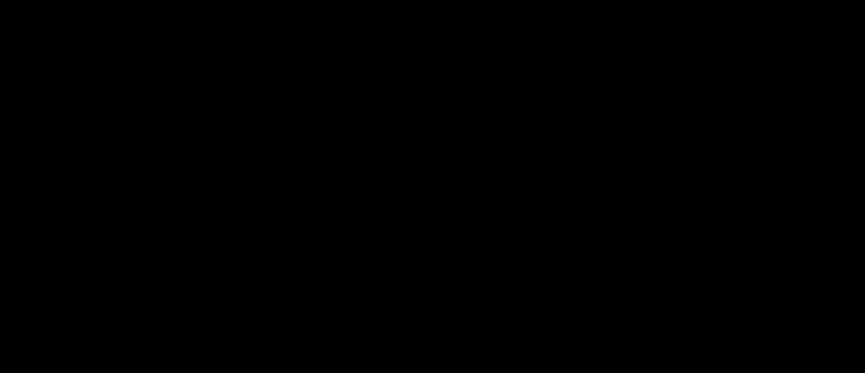
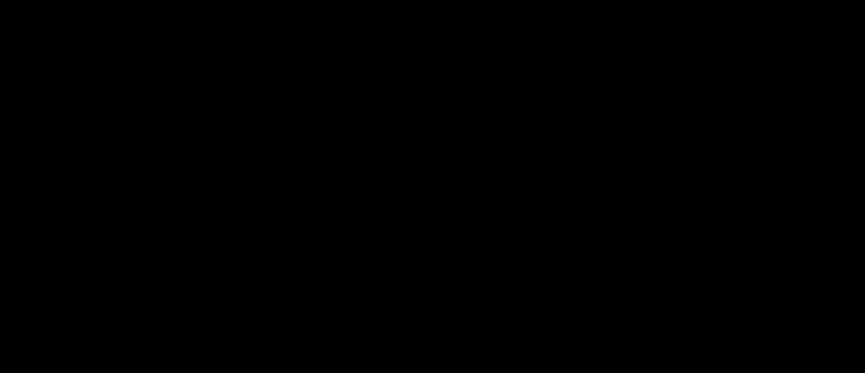

In [3]:
#Bunlar dersteki Python kütüphaneleri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score

file_path = 'data/diabetic+retinopathy+debrecen/messidor_features.arff' #arff dosyası bizim veriyi aldığımız dosyadır. Onu bir değşkene (obje) eşitliyoruz ki istediğimizde çağırabilelim.
data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)
print(df)


X = df.iloc[:, :-1] #Bu kod tüm satırları alırken, en son sütunu almıyor. Sebebi ise sadece y ekseninde bize lazım olması.

y = df.iloc[:, -1].to_frame() #Bu kod aynı şekilde tüm satırları alırken bu sefer sadece son sütunu alıyor.

# y'deki byte stringleri (b'0', b'1') temiz sayıya (0, 1) çevirme
# (Bu, veriyi modelin anlayacağı sayısal formata getirir. Ders slaytlarında bu decoding vardı.)
y['Class'] = y['Class'].str.decode('utf-8').astype(int)

print("Yüklemeler ve instance ayarlamarı tamamdır.")

        0    1     2     3     4     5     6     7          8          9  \
0     1.0  1.0  22.0  22.0  22.0  19.0  18.0  14.0  49.895756  17.775994   
1     1.0  1.0  24.0  24.0  22.0  18.0  16.0  13.0  57.709936  23.799994   
2     1.0  1.0  62.0  60.0  59.0  54.0  47.0  33.0  55.831441  27.993933   
3     1.0  1.0  55.0  53.0  53.0  50.0  43.0  31.0  40.467228  18.445954   
4     1.0  1.0  44.0  44.0  44.0  41.0  39.0  27.0  18.026254   8.570709   
...   ...  ...   ...   ...   ...   ...   ...   ...        ...        ...   
1146  1.0  1.0  34.0  34.0  34.0  33.0  31.0  24.0   6.071765   0.937472   
1147  1.0  1.0  49.0  49.0  49.0  49.0  45.0  37.0  63.197145  27.377668   
1148  1.0  0.0  49.0  48.0  48.0  45.0  43.0  33.0  30.461898  13.966980   
1149  1.0  1.0  39.0  36.0  29.0  23.0  13.0   7.0  40.525739  12.604947   
1150  1.0  1.0   7.0   7.0   7.0   7.0   7.0   5.0  69.423565   7.031843   

             10        11        12        13        14        15        16  \
0      5

In [4]:
X.info() #Bu kod satırı bize verilerde herhangi bir null değer var mı onu gösteriyor. 0'dan 18'e kadar olan sütunların hepsindeki 1151 satırdaki değerler non-null. O yüzden eksik veri yok. Yani imputation işlemi yapmıyoruz.
X.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1151 non-null   float64
 1   1       1151 non-null   float64
 2   2       1151 non-null   float64
 3   3       1151 non-null   float64
 4   4       1151 non-null   float64
 5   5       1151 non-null   float64
 6   6       1151 non-null   float64
 7   7       1151 non-null   float64
 8   8       1151 non-null   float64
 9   9       1151 non-null   float64
 10  10      1151 non-null   float64
 11  11      1151 non-null   float64
 12  12      1151 non-null   float64
 13  13      1151 non-null   float64
 14  14      1151 non-null   float64
 15  15      1151 non-null   float64
 16  16      1151 non-null   float64
 17  17      1151 non-null   float64
 18  18      1151 non-null   float64
dtypes: float64(19)
memory usage: 171.0 KB


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1.0,1.0,22.0,22.0,22.0,19.0,18.0,14.0,49.895756,17.775994,5.270920,0.771761,0.018632,0.006864,0.003923,0.003923,0.486903,0.100025,1.0
1,1.0,1.0,24.0,24.0,22.0,18.0,16.0,13.0,57.709936,23.799994,3.325423,0.234185,0.003903,0.003903,0.003903,0.003903,0.520908,0.144414,0.0
2,1.0,1.0,62.0,60.0,59.0,54.0,47.0,33.0,55.831441,27.993933,12.687485,4.852282,1.393889,0.373252,0.041817,0.007744,0.530904,0.128548,0.0
3,1.0,1.0,55.0,53.0,53.0,50.0,43.0,31.0,40.467228,18.445954,9.118901,3.079428,0.840261,0.272434,0.007653,0.001531,0.483284,0.114790,0.0
4,1.0,1.0,44.0,44.0,44.0,41.0,39.0,27.0,18.026254,8.570709,0.410381,0.000000,0.000000,0.000000,0.000000,0.000000,0.475935,0.123572,0.0


In [5]:
y.value_counts() #Bu kod satırı da bize verilerimizin degeli olduğunu gösteriyor. Yani hasta olanlar ve olmayanların sayısı orantısal olarak birbirine yakın olduğundan veri setimizi ekstradan düzenlememize gerek yok.

Class
1        611
0        540
Name: count, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y) #Verimizin yüzde 80'i eğitim, kalanı eğitim için kullanılacak. Stratify = y, classların yani hasta/hasta değil oranlarını sabit tutar her set için.

print(y_train.value_counts(normalize=True)) #Yukarıda yaptığımızın aynısı. Stratify durumu kontrol ediyor. Oran aynı sıkıntı yok.

Class
1        0.530435
0        0.469565
Name: proportion, dtype: float64


In [7]:
scaler = StandardScaler()#Scaler tanımlıyoruz. Değeri 1000'li olanla 10'lu olan aynı ağırlıkta.

X_train_scaled = scaler.fit_transform(X_train)#Standadizasyon için standart sapma lazım. Onu sadece burda hesaplıyoruz. Sonra X_traini standardize ediyoruz.

X_test_scaled = scaler.transform(X_test)#Standardizasyonu burda da yapıyoruz ama burda standart sapmayı bulmuyoruz. Burda standart sapma bulma yok çünkü testten bu değeri alırsak model buna göre eğitilebilir. Overfit olabilir.
